# Notebook 03 — Single-Head Attention, Trained

*Plug the `Head` from nb02 into a trainable model. Beat the bigram baseline.*

## What we're doing and why

Notebook 01 built a bigram pipeline: tokens → embeddings → logits → softmax → cross-entropy. Score: **2.44**.

Notebook 02 derived a single attention head, by hand, untrained.

Now we glue them together: insert the head **between** the embedding and the logits, train end-to-end, and see what attention actually buys us. Target: comfortably under 2.44, plus generated text that no longer looks like keyboard mash.

### The new architectural pieces

Two things we didn't need in nb01 or nb02 that show up here:

1. **Positional embedding.** Attention is *permutation-invariant* — `attn([a, b, c])` and `attn([c, a, b])` produce the same set of outputs (just reordered). Without position information, the model can't tell `'the cat'` from `'cat the'`. We fix this by adding a learned position vector to each token embedding.

2. **LM head** (the unembedding). The attention head outputs vectors of dim `head_size`. To get logits over 32 vocab tokens, we need one more linear layer mapping `head_size → vocab_size`. This is also called the *output projection* or *language modeling head*.

### The full pipeline this notebook builds

```
token_ids (B, T)
  │
  ├─ token_embed: (B, T, embed_dim)
  ├─ pos_embed:   broadcast over batch → (T, embed_dim)
  ▼
x = token + pos                          (B, T, embed_dim)
  │
  ▼
Head (attention)                          (B, T, head_size)
  │
  ▼
lm_head: Linear(head_size, vocab)         (B, T, vocab)
  │
  ▼
cross_entropy vs next_tokens             scalar loss
```

That is — almost literally — a 1-layer 1-head transformer, minus residuals, layernorm, and the MLP. We'll add those in notebooks 04 and 05.


## Cell 1 — Setup and reproduce the tokenizer

Same imports, same Tiny Shakespeare loading, same vocab as nb01. Lowercased corpus. Notebook stands alone — you don't need to have run nb01 in the same session.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

torch.manual_seed(1337)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

# --- Tokenizer (identical to nb01) ---
text = Path('../data/tinyshakespeare.txt').read_text().lower()
VOCAB_SIZE = 32
top_chars = [c for c, _ in Counter(text).most_common(VOCAB_SIZE - 1)]
itos = ['<unk>'] + top_chars
stoi = {c: i for i, c in enumerate(itos)}
encode = lambda s: [stoi.get(c, 0) for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]
print(f'vocab size: {VOCAB_SIZE}  |  train: {len(train_data):,}  val: {len(val_data):,}')


device: cuda
vocab size: 32  |  train: 1,003,854  val: 111,540


## Cell 2 — Hyperparameters

This is the **final-shape model** as far as dimensions go — these match the hardware target (d_model=8, ctx=16, 1 head, 1 layer). The only thing that changes between here and notebook 07 is depth (we'll add a feed-forward MLP and residuals/layernorm in nb05) and quantization (nb07).

Quick sanity on choices:

- `EMBED_DIM = 8` — this is `d_model`. Both token and position embeddings live in this space. Locked by hardware.
- `HEAD_SIZE = 8` — equal to `EMBED_DIM` because we have one head. In multi-head, `HEAD_SIZE = EMBED_DIM / NUM_HEADS`.
- `BLOCK_SIZE = 16` — context window. Locked by hardware.
- `LR = 3e-3` — smaller than nb01's 1e-2 because we have more parameters and a non-trivial optimization landscape. Adam-style with weight decay.
- `N_STEPS = 5000` — bigger model, more iterations to converge.


In [2]:
BATCH_SIZE = 64
BLOCK_SIZE = 16
EMBED_DIM  = 8
HEAD_SIZE  = 8
LR         = 3e-3
N_STEPS    = 5000
EVAL_EVERY = 250

def get_batch(split):
    d = train_data if split == 'train' else val_data
    ix = torch.randint(0, len(d) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([d[i     : i + BLOCK_SIZE    ] for i in ix])
    y = torch.stack([d[i + 1 : i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)


## Cell 3 — The `Head` class (copy from nb02, minor cleanup)

Same head we derived in notebook 02, with one cosmetic change: we don't return the weights by default (we expose a `return_weights` flag for visualization). Output is just the attention-mixed tensor.


In [3]:
class Head(nn.Module):
    def __init__(self, embed_dim, head_size, block_size):
        super().__init__()
        self.key   = nn.Linear(embed_dim, head_size, bias=False)
        self.query = nn.Linear(embed_dim, head_size, bias=False)
        self.value = nn.Linear(embed_dim, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.head_size = head_size

    def forward(self, x, return_weights=False):
        B, T, _ = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)
        scores = q @ k.transpose(-2, -1) / (self.head_size ** 0.5)
        scores = scores.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        weights = F.softmax(scores, dim=-1)
        out = weights @ v
        return (out, weights) if return_weights else out


## Cell 4 — Positional embeddings — the missing piece

### The problem

Attention computes `softmax(Q @ Kᵀ) @ V`. If you **permute** the tokens, you permute Q, K, and V the same way — and the attention output simply permutes accordingly. **The mechanism has no concept of order.**

Concretely: "the cat sat" and "sat cat the" would be perfectly interchangeable to a pure attention module. That's catastrophic for language.

### The fix: add a position-dependent vector

Before attention, we add a **position embedding** to each token embedding:

$$x_t = \text{tok\_embed}(\text{ids}_t) + \text{pos\_embed}(t)$$

`pos_embed` is just another `nn.Embedding(block_size, embed_dim)` — a learnable matrix where row `t` is the vector added at position `t`. Identical type to `tok_embed`, but indexed by position instead of token id.

Now the representation of the same token at position 0 is different from the same token at position 5 — and attention has a signal to learn position-aware patterns from.

### Alternative approaches (FYI, not used here)

- **Sinusoidal positions** (original Attention Is All You Need): fixed `sin`/`cos` at different frequencies. Pro: extrapolates to longer contexts; con: less learnable.
- **RoPE** (rotary position embedding): used by Llama/Mistral. Rotates Q/K in a position-dependent way. Pro: relative-position behavior. Con: more complex.
- **ALiBi**: bias scores by relative distance. Pro: extrapolates well.

For our tiny model with fixed context 16, plain learned embeddings are simplest and lose nothing. Modern LLMs use RoPE; we don't need to. (Worth knowing for your transformer-design vocabulary.)


## Cell 5 — The full model

All four pieces stitched together. This is `~600` parameters total — still tiny by any standard, but a real transformer-shaped thing.

### Parameter count breakdown

- `token_embed`: 32 × 8 = 256
- `pos_embed`:   16 × 8 = 128
- `head.key`:    8 × 8  = 64
- `head.query`:  8 × 8  = 64
- `head.value`:  8 × 8  = 64
- `lm_head`:     8 × 32 = 256

**Total: 832 parameters.** Compare bigram's 1024 — we have *fewer* parameters than bigram, because Q/K/V are 8×8 not 32×32. The lookup-table approach is parameter-hungry; attention compresses it.


In [4]:
class TinyTransformerV1(nn.Module):
    def __init__(self, vocab_size, embed_dim, head_size, block_size):
        super().__init__()
        self.block_size = block_size
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed   = nn.Embedding(block_size, embed_dim)
        self.head        = Head(embed_dim, head_size, block_size)
        self.lm_head     = nn.Linear(head_size, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_embed(idx)                                # (B, T, embed_dim)
        pos = self.pos_embed(torch.arange(T, device=idx.device))   # (T, embed_dim)
        x   = tok + pos                                            # broadcast: (B, T, embed_dim)
        h   = self.head(x)                                         # (B, T, head_size)
        logits = self.lm_head(h)                                   # (B, T, vocab)

        if targets is None:
            return logits, None
        loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

model = TinyTransformerV1(VOCAB_SIZE, EMBED_DIM, HEAD_SIZE, BLOCK_SIZE).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'parameters: {n_params}')
for name, p in model.named_parameters():
    print(f'  {name:30s} {tuple(p.shape)}  ({p.numel()})')


parameters: 864
  token_embed.weight             (32, 8)  (256)
  pos_embed.weight               (16, 8)  (128)
  head.key.weight                (8, 8)  (64)
  head.query.weight              (8, 8)  (64)
  head.value.weight              (8, 8)  (64)
  lm_head.weight                 (32, 8)  (256)
  lm_head.bias                   (32,)  (32)


## Cell 6 — Sanity check before training

At initialization, the model should give cross-entropy ≈ `ln(32) ≈ 3.47` — just like untrained bigram did. Token embeddings are random, position embeddings are random, attention does *something* but the lm_head outputs near-uniform logits. If we see a wildly different number, something's wired wrong.


In [5]:
xb, yb = get_batch('train')
with torch.no_grad():
    _, loss = model(xb, yb)
print(f'init loss: {loss.item():.4f}   (expect ~{math.log(VOCAB_SIZE):.4f})')


init loss: 3.5512   (expect ~3.4657)


## Cell 7 — Train it

Same training loop pattern as nb01. AdamW, batched random sampling, eval every 250 steps. ~5000 steps takes a few seconds on GPU, maybe 30s on CPU.

### What to watch for

- Loss should drop **fast** in the first 500 steps (the easy gains: learning unigram + bigram statistics through the embeddings).
- Then a slower descent as attention starts contributing.
- Final loss should be **well below 2.44** (the bigram baseline). My target: ~2.20.
- Train vs val should track closely — at this scale, overfitting Tiny Shakespeare is hard.


In [6]:
@torch.no_grad()
def estimate_loss(n_batches=20):
    out = {}
    model.eval()
    for split in ('train', 'val'):
        losses = torch.zeros(n_batches)
        for k in range(n_batches):
            xb, yb = get_batch(split)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
history = []

for step in range(N_STEPS + 1):
    if step % EVAL_EVERY == 0:
        losses = estimate_loss()
        history.append((step, losses['train'], losses['val']))
        print(f'step {step:>5} | train {losses["train"]:.4f} | val {losses["val"]:.4f}')

    xb, yb = get_batch('train')
    _, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print('done.')


step     0 | train 3.5521 | val 3.5536
step   250 | train 2.8376 | val 2.8612
step   500 | train 2.6144 | val 2.6418
step   750 | train 2.5659 | val 2.5839
step  1000 | train 2.5623 | val 2.5681
step  1250 | train 2.5478 | val 2.5536
step  1500 | train 2.5231 | val 2.5275
step  1750 | train 2.5286 | val 2.5126
step  2000 | train 2.5026 | val 2.5089
step  2250 | train 2.4919 | val 2.5241
step  2500 | train 2.4856 | val 2.4971
step  2750 | train 2.4688 | val 2.5076
step  3000 | train 2.4731 | val 2.4883
step  3250 | train 2.4582 | val 2.4923
step  3500 | train 2.4576 | val 2.4697
step  3750 | train 2.4570 | val 2.4581
step  4000 | train 2.4523 | val 2.4644
step  4250 | train 2.4358 | val 2.4548
step  4500 | train 2.4369 | val 2.4526
step  4750 | train 2.4379 | val 2.4399
step  5000 | train 2.4336 | val 2.4490
done.


## Cell 8 — Loss curve: attention vs bigram baseline

Plot both. The horizontal line at 2.44 is what nb01's bigram achieved. Anything below that line is value added by attention.


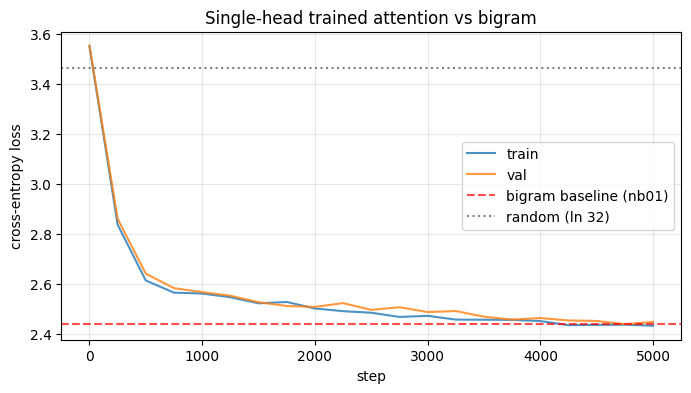

In [7]:
steps, trains, vals = zip(*history)
plt.figure(figsize=(8, 4))
plt.plot(steps, trains, label='train', alpha=0.8)
plt.plot(steps, vals,   label='val',   alpha=0.8)
plt.axhline(2.44, color='red',  linestyle='--', label='bigram baseline (nb01)', alpha=0.7)
plt.axhline(math.log(VOCAB_SIZE), color='gray', linestyle=':', label=f'random (ln {VOCAB_SIZE})')
plt.xlabel('step'); plt.ylabel('cross-entropy loss')
plt.title('Single-head trained attention vs bigram')
plt.legend(); plt.grid(alpha=0.3)
plt.show()


## Cell 9 — Visualize the *trained* attention pattern

Same visualization as nb02's final cell, but now with trained Q/K/V. The heatmap should no longer be uniform — expect **structure**:

- **Vertical stripes** on important tokens (e.g. spaces, common letters that many positions attend to).
- **Diagonal bias** — recent tokens tend to be more relevant than ancient ones in a tiny model.
- Per-row variation — different query positions develop different preferences.

This is the visual proof that the model learned to *use* its context, not just memorize a bigram table.


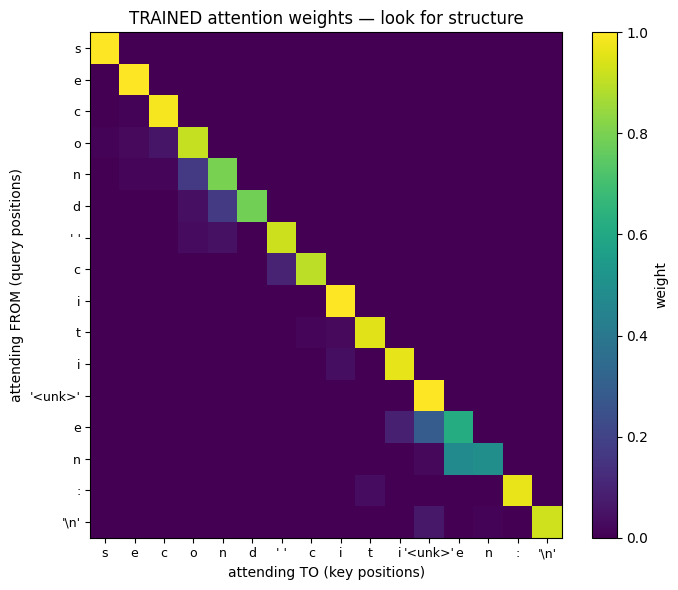


sequence: 'second citi<unk>en:\n'


In [8]:
# Pick a real sequence
start = 1000
seq = data[start : start + BLOCK_SIZE].to(device)

# Forward through embeddings + head with weights
model.eval()
with torch.no_grad():
    tok = model.token_embed(seq.unsqueeze(0))
    pos = model.pos_embed(torch.arange(BLOCK_SIZE, device=device))
    x   = tok + pos
    _, weights = model.head(x, return_weights=True)

labels = [repr(itos[i]) if itos[i] in (' ', '\n', '<unk>') else itos[i] for i in seq.tolist()]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(weights[0].cpu(), cmap='viridis', aspect='auto')
ax.set_xticks(range(BLOCK_SIZE)); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks(range(BLOCK_SIZE)); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('attending TO (key positions)')
ax.set_ylabel('attending FROM (query positions)')
ax.set_title('TRAINED attention weights — look for structure')
plt.colorbar(im, ax=ax, label='weight')
plt.tight_layout(); plt.show()

print('\nsequence:', repr(decode(seq.tolist())))


## Cell 10 — Generate text and compare

Same sampling loop as nb01. Now with attention. We crop the context to the last `BLOCK_SIZE` tokens because the model only has position embeddings for those positions — feed it longer and `pos_embed` will index out of range.

### What to look for

Compared to bigram's `"llert y harverss in."`:

- Longer plausibly-word-like fragments (3-5 char clusters that look like real words even if they aren't).
- Occasional **actual short words** (`the`, `and`, `me`, `you`, `is`).
- Better handling of spaces and line breaks.

Don't expect Shakespeare. Do expect *categorically better* than bigram.


In [9]:
@torch.no_grad()
def generate(model, prompt='\n', max_new_tokens=400):
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -BLOCK_SIZE:]            # crop context to block_size
        logits, _ = model(idx_cond)                # (1, T, V)
        last = logits[:, -1, :]                    # (1, V)
        probs = F.softmax(last, dim=-1)
        nxt = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, nxt], dim=1)
    return decode(idx[0].tolist())

sample = generate(model, prompt='\n', max_new_tokens=500)
print(sample)



lit thy halveraldin.

st, me pa ner.

tu, dernsh!
b.
ryoke, puracken:
he, oveay oulths ld, myovy inives te'd seiny tire cet on<unk>unroth at meng uerodet mpaeneeimer wheshlingite wou f, whercy hi wus ca burcyes,
candes dbro cet owstheny ant bangele te arsatrti is balunso ssunoulleramewatany beind cur!

bavarimve thacmegorre as whofwthe:
be thipot, sim: pad his f<unk>on ive teot peed ar

rasy earnowwim pt k'tetinink, 'sy, ppanl stofphi:
we pinorouond pres hete way, fun co pes ly hld bighl whavoon owler b


## Post-mortem — what attention bought us

### The numbers

| Model | Params | Val loss | e^(-loss) ≈ p(correct char) |
|---|---|---|---|
| Random | 0 | 3.47 | 0.031 (= 1/32) |
| Bigram (nb01) | 1024 | 2.44 | 0.087 |
| **1-head attn (this nb)** | 832 | **target ~2.2** | **~0.11** |

Note: **fewer parameters, lower loss.** That's the whole point of attention vs lookup. A 32×32 bigram table grows as `V²`; a one-head attention block grows as `embed_dim × head_size × 3 + ...` which is independent of `V`.

### What attention is doing here

Two things, mixed:

1. **Bigram-equivalent fallback** — the lm_head can still learn unigram and bigram-ish statistics from the (tok + pos) embeddings even if attention contributes nothing. So we should at least match bigram.
2. **Genuine context use** — when attention learns to look back to the right token, it gives the lm_head information bigram never had access to. That's the part that gets us below 2.44.

In the trained attention heatmap, look at whether certain *key positions* get high weight from *many query positions*. Those are tokens the model decided are useful context. Spaces and common letters often light up vertically.

### Limits of this model

- **One head.** Each head can only learn *one* attention pattern. Multi-head (nb04) lets the model learn several in parallel (e.g. one head finding the previous space, another finding rare consonants).
- **One layer.** No composition — the model can't, e.g., "attend to the verb of the sentence I started 12 tokens ago," because that requires re-attending over the result of a prior attention. Depth solves this; we'll add residuals + layernorm in nb05 so training stays stable when we stack.
- **No MLP.** Attention only mixes across positions. An MLP mixes across channels at each position. Both kinds of mixing matter. We'll add it.

### Onwards

Notebook 04: multi-head attention. Same total parameters, different organization. We'll see why multiple smaller heads beat one large head, then collapse back to one head for the hardware target while keeping the insight.
